# The Ranking System — Which 100 Merchants Should We Onboard?

**Buy Now, Pay Later merchant ranking | MAST30034 Applied Data Science**

The firm can onboard at most 100 of roughly 4,000 interested merchants this
year. This notebook explains how we chose them.

The question we are answering is deliberately **not** "who is the biggest
merchant?" It is "which hundred partnerships will earn us the most, without
exposing us to risk we can't price?" Those are different questions, and a
ranking built on transaction volume answers the wrong one.

Run `python scripts/etl_04_ranking.py` before this notebook.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
import config
from etl_04_ranking import PILLAR_WEIGHTS, RISK_WEIGHTS

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3})

rankings = pd.read_parquet(config.CURATED_DIR / "merchant_rankings.parquet")
established = rankings[rankings["cohort"] == "established"]

print(f"merchants scored:        {len(rankings):,}")
print(f"established cohort:      {len(established):,}")
print(f"insufficient history:    {len(rankings) - len(established):,}")

merchants scored:        4,005
established cohort:      3,172
insufficient history:    833


## 1. How the score is built

Three pillars, each answering a question a partnerships manager would actually
ask about a prospective merchant.

| Pillar | Weight | The question it answers |
|---|---|---|
| **Value** | 0.50 | How much will this merchant earn us next year? |
| **Growth** | 0.25 | Is that number heading up or down? |
| **Risk** | 0.25 | How likely is that number to be wrong, or to disappear? |

### Why percentiles rather than raw values

The underlying features are enormously skewed — the largest merchant processes
tens of thousands of times more transactions than the smallest. A weighted sum
of raw values would be a ranking of transaction volume with three decorative
extra terms, no matter what weights we chose. Converting each pillar to a
percentile first puts them on the same 0–1 footing, so the weights mean what
they say.

In [2]:
pillars = pd.DataFrame({
    "pillar": list(PILLAR_WEIGHTS.keys()),
    "weight": list(PILLAR_WEIGHTS.values()),
})
risk = pd.DataFrame({
    "risk component": list(RISK_WEIGHTS.keys()),
    "weight within risk": list(RISK_WEIGHTS.values()),
})
display(pillars)
display(risk)

,pillar,weight
0,value,0.50
1,growth,0.25
2,risk,0.25


,risk component,weight within risk
0,revenue_volatility,0.30
1,customer_hhi,0.30
2,excluded_share,0.20
3,inactivity,0.20


### The headline number

`projected_annual_revenue` is the one quantity here that a non-technical
stakeholder can price directly: the dollars we expect this merchant to generate
for the firm over the next twelve months, calculated as their observed monthly
revenue extended forward and adjusted by their revenue trend.

The trend adjustment is clipped at ±30%. Without a clip, a merchant whose
revenue happened to double across a nine-month window projects to an absurd
figure and takes the top of the ranking on noise.

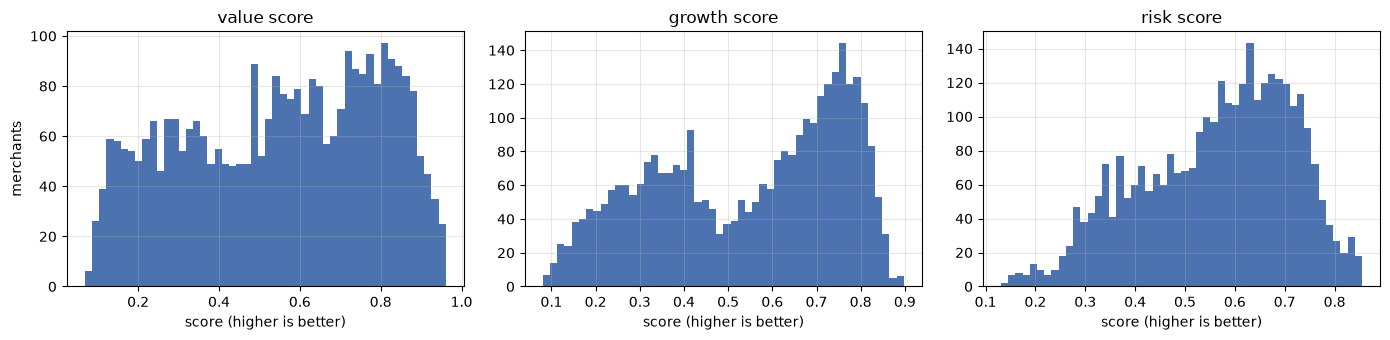

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, pillar in zip(axes, ["value_score", "growth_score", "risk_score"]):
    ax.hist(established[pillar], bins=50, color="#4C72B0")
    ax.set(title=pillar.replace("_", " "), xlabel="score (higher is better)")
axes[0].set_ylabel("merchants")
plt.tight_layout()
plt.show()

## 2. Is this just a revenue ranking in disguise?

This is the question a sceptical stakeholder should ask, and we should answer it
honestly rather than hope nobody does.

In [4]:
diagnostics = pd.Series({
    "final score vs projected revenue (Spearman)":
        established["final_score"].corr(established["projected_annual_revenue"], method="spearman"),
    "final score vs transaction count (Spearman)":
        established["final_score"].corr(established["n_transactions"], method="spearman"),
})
display(diagnostics.round(3).to_frame("correlation"))

by_score = set(established.nsmallest(100, "overall_rank")["merchant_abn"])
by_revenue = set(established.nlargest(100, "projected_annual_revenue")["merchant_abn"])
print(f"\nMerchants in both top-100 lists: {len(by_score & by_revenue)}")
print(f"In our top 100 but NOT the top 100 by revenue alone: {len(by_score - by_revenue)}")

,correlation
final score vs projected revenue (Spearman),0.93
final score vs transaction count (Spearman),0.86



Merchants in both top-100 lists: 67
In our top 100 but NOT the top 100 by revenue alone: 33


**The honest answer: it is revenue-dominated, but not revenue alone.**

The rank correlation with projected revenue is high, which is expected and
arguably correct — the firm is paid a percentage of transaction value, so a
ranking that ignored revenue would be indefensible. But the overlap between our
top 100 and a naive top 100 by revenue is only around two thirds. Roughly a
third of the list changes once growth and risk are considered.

Those swapped-in merchants are where the system earns its keep. Below are the
merchants that a pure revenue ranking would have missed.

In [5]:
swapped_in = established[
    established["merchant_abn"].isin(by_score - by_revenue)
].nsmallest(10, "overall_rank")

swapped_in[[
    "overall_rank", "merchant_name", "segment", "projected_annual_revenue",
    "growth_score", "risk_score", "final_score",
]]

,overall_rank,merchant_name,segment,projected_annual_revenue,growth_score,risk_score,final_score
4,5.00,Lobortis Class Industries,Home & Garden,"92,643.23",0.79,0.84,0.87
11,12.00,Dignissim Lacus PC,Hobby & Recreation,"84,352.12",0.71,0.83,0.86
16,17.00,Libero Et Limited,Home & Garden,"87,641.59",0.78,0.82,0.85
24,25.00,Tempor Est Ac Corporation,Home & Garden,"56,139.83",0.77,0.82,0.85
29,30.00,Auctor Vitae Inc.,Hobby & Recreation,"59,722.50",0.78,0.81,0.85
40,41.00,Dictum Augue Consulting,Speciality Retail,"48,383.36",0.82,0.78,0.84
43,44.00,Lectus Limited,Technology & Telecom,"52,789.09",0.79,0.81,0.84
46,47.00,Nec Ante Foundation,Speciality Retail,"57,356.41",0.78,0.76,0.84
47,48.00,Arcu Morbi Institute,Hobby & Recreation,"89,627.90",0.68,0.79,0.84
51,52.00,Et PC,Home & Garden,"48,235.85",0.78,0.85,0.84


In [6]:
# And the mirror image: high revenue, but kept out of the top 100.
excluded = established[
    established["merchant_abn"].isin(by_revenue - by_score)
].nlargest(10, "projected_annual_revenue")

excluded[[
    "overall_rank", "merchant_name", "segment", "projected_annual_revenue",
    "revenue_volatility", "customer_hhi", "growth_score", "risk_score",
]]

,overall_rank,merchant_name,segment,projected_annual_revenue,revenue_volatility,customer_hhi,growth_score,risk_score
188,189.00,Amet Risus Inc.,Home & Garden,"362,677.88",0.38,0.00,0.65,0.64
171,172.00,Lacus Consulting,Speciality Retail,"361,834.30",0.37,0.00,0.71,0.71
142,143.00,Etiam Bibendum Industries,Home & Garden,"322,241.20",0.38,0.00,0.66,0.67
115,116.00,Nullam Consulting,Technology & Telecom,"276,349.43",0.37,0.00,0.68,0.78
684,685.00,Commodo Ipsum Industries,Luxury & Personal Care,"251,316.49",0.41,0.00,0.48,0.58
596,597.00,Lacus Aliquam Corporation,Hobby & Recreation,"243,153.56",0.40,0.00,0.55,0.53
161,162.00,Ac Ipsum LLC,Home & Garden,"243,121.15",0.39,0.00,0.67,0.64
125,126.00,Diam Eu Dolor LLC,Home & Garden,"240,555.33",0.38,0.00,0.65,0.70
107,108.00,Suspendisse Ac Associates,Technology & Telecom,"204,363.58",0.37,0.00,0.69,0.76
129,130.00,Euismod In Corp.,Hobby & Recreation,"189,142.07",0.37,0.00,0.68,0.74


Read the second table alongside the first. The merchants held out of the top 100
despite strong revenue are generally there for one of two reasons: their revenue
swings sharply month to month, or it rests on a small number of customers. Both
are reasons a partnerships manager would hesitate, and both are exactly what the
risk pillar was built to catch.

## 3. The top 100

### What they are worth

In [7]:
top_100 = established.nsmallest(100, "overall_rank")

share_of_revenue = (
    100 * top_100["projected_annual_revenue"].sum()
    / established["projected_annual_revenue"].sum()
)
share_of_merchants = 100 * len(top_100) / len(established)

print(f"projected annual revenue from the top 100: "
      f"${top_100['projected_annual_revenue'].sum():,.0f}")
print(f"that is {share_of_revenue:.1f}% of the established book, "
      f"from {share_of_merchants:.1f}% of merchants")

projected annual revenue from the top 100: $16,539,883
that is 28.7% of the established book, from 3.2% of merchants


This is the number for the first slide. **Onboarding 3% of interested merchants
captures roughly 29% of the available revenue.** The constraint the firm is
operating under — only 100 slots — is far less costly than it sounds, provided
the 100 are chosen well.

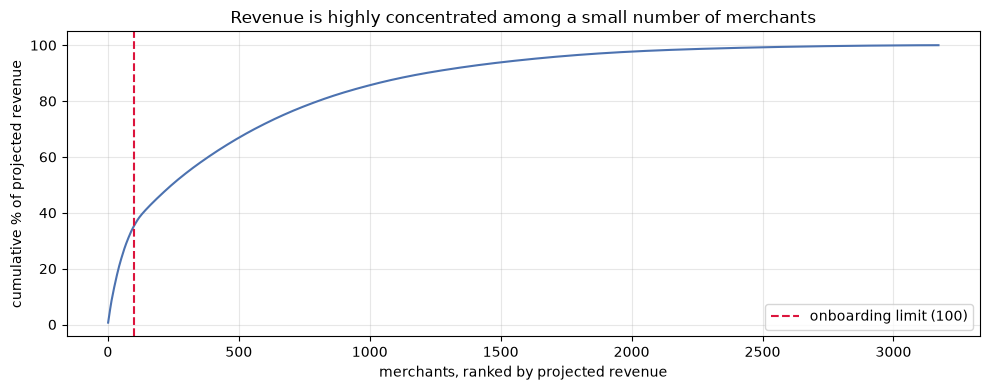

In [8]:
ordered = established.sort_values("projected_annual_revenue", ascending=False)
cumulative = 100 * ordered["projected_annual_revenue"].cumsum() / ordered["projected_annual_revenue"].sum()

fig, ax = plt.subplots()
ax.plot(range(1, len(cumulative) + 1), cumulative.values, color="#4C72B0")
ax.axvline(100, color="crimson", linestyle="--", label="onboarding limit (100)")
ax.set(xlabel="merchants, ranked by projected revenue",
       ylabel="cumulative % of projected revenue",
       title="Revenue is highly concentrated among a small number of merchants")
ax.legend()
plt.tight_layout()
plt.show()

### Segment composition

The top 100 is not dominated by any single segment, which is a useful property
in itself — a partnership book concentrated in one vertical rises and falls with
that vertical.

In [9]:
composition = pd.DataFrame({
    "in top 100": top_100["segment"].value_counts(),
    "in full book": established["segment"].value_counts(),
})
composition["% of segment selected"] = 100 * composition["in top 100"] / composition["in full book"]
composition

,in top 100,in full book,% of segment selected
segment,,,
Hobby & Recreation,26,681,3.82
Home & Garden,25,645,3.88
Luxury & Personal Care,13,633,2.05
Speciality Retail,18,465,3.87
Technology & Telecom,18,748,2.41


In [10]:
top_100[[
    "overall_rank", "merchant_name", "segment", "category", "take_rate",
    "projected_annual_revenue", "n_customers", "mean_basket", "final_score",
]].head(25)

,overall_rank,merchant_name,segment,category,take_rate,projected_annual_revenue,n_customers,mean_basket,final_score
0,1.00,Nec Incorporated,Technology & Telecom,telecom,5.55,"346,099.24",2123,"1,917.08",0.88
1,2.00,Adipiscing Elit Foundation,Technology & Telecom,"computers, computer peripheral equipment, and ...",5.82,"259,918.29",5844,453.43,0.87
2,3.00,Suspendisse Non Leo PC,Speciality Retail,motor vehicle supplies and new parts,3.10,"171,504.66",8247,378.68,0.87
3,4.00,Odio Phasellus Institute,Hobby & Recreation,artist supply and craft shops,6.59,"347,252.73",4369,743.23,0.87
4,5.00,Lobortis Class Industries,Home & Garden,"lawn and garden supply outlets, including nurs...",2.49,"92,643.23",8600,238.25,0.87
5,6.00,Aliquam Auctor Associates,Hobby & Recreation,"antique shops - sales, repairs, and restoratio...",4.20,"202,254.95",11268,215.90,0.87
6,7.00,Phasellus At Limited,Home & Garden,"furniture, home furnishings and equipment shop...",4.65,"270,605.71",12967,215.66,0.86
7,8.00,Pretium Et LLC,Speciality Retail,"stationery, office supplies and printing and w...",5.53,"218,002.07",3993,615.35,0.86
8,9.00,Gravida Mauris Incorporated,Luxury & Personal Care,"watch, clock, and jewelry repair shops",6.35,"310,512.83",14510,151.62,0.86
9,10.00,Arcu Sed Eu Incorporated,Technology & Telecom,"computer programming, data processing, and int...",4.80,"281,401.24",11680,249.02,0.86


## 4. Top 10 within each segment

Ranking within segment matters because segments are not commensurable. A
merchant with a $50 basket and thousands of orders and one with a $3,000 basket
and a few hundred are not competing for the same partnership slot, and comparing
them directly favours whichever business model happens to move more dollars.

In [11]:
segment_leaders = (
    established[established["segment_rank"] <= 10]
    .sort_values(["segment", "segment_rank"])
)

for segment in sorted(segment_leaders["segment"].unique()):
    print(f"\n=== {segment} ===")
    display(
        segment_leaders[segment_leaders["segment"] == segment][[
            "segment_rank", "merchant_name", "category",
            "projected_annual_revenue", "n_customers", "final_score",
        ]]
    )


=== Hobby & Recreation ===


,segment_rank,merchant_name,category,projected_annual_revenue,n_customers,final_score
3,1.00,Odio Phasellus Institute,artist supply and craft shops,"347,252.73",4369,0.87
5,2.00,Aliquam Auctor Associates,"antique shops - sales, repairs, and restoratio...","202,254.95",11268,0.87
11,3.00,Dignissim Lacus PC,"music shops - musical instruments, pianos, and...","84,352.12",4811,0.86
13,4.00,Lobortis Ultrices Company,"music shops - musical instruments, pianos, and...","345,860.02",20839,0.86
18,5.00,Ornare Fusce Inc.,"hobby, toy and game shops","252,417.16",14918,0.85
20,6.00,Vel Turpis Aliquam Company,bicycle shops - sales and service,"138,979.86",3119,0.85
25,7.00,Magna Malesuada Corp.,artist supply and craft shops,"277,071.46",4750,0.85
29,8.00,Auctor Vitae Inc.,bicycle shops - sales and service,"59,722.50",6723,0.85
30,9.00,Mattis Velit Justo Ltd,artist supply and craft shops,"154,343.23",2397,0.85
33,10.00,Elit Sed Consequat Associates,artist supply and craft shops,"279,634.79",4944,0.84



=== Home & Garden ===


,segment_rank,merchant_name,category,projected_annual_revenue,n_customers,final_score
4,1.00,Lobortis Class Industries,"lawn and garden supply outlets, including nurs...","92,643.23",8600,0.87
6,2.00,Phasellus At Limited,"furniture, home furnishings and equipment shop...","270,605.71",12967,0.86
16,3.00,Libero Et Limited,"furniture, home furnishings and equipment shop...","87,641.59",12769,0.85
17,4.00,Sodales Elit Erat Corporation,"lawn and garden supply outlets, including nurs...","98,789.06",3692,0.85
19,5.00,Iaculis Aliquet Diam LLC,"lawn and garden supply outlets, including nurs...","105,008.43",9862,0.85
21,6.00,Phasellus Dapibus Incorporated,"furniture, home furnishings and equipment shop...","150,804.25",11215,0.85
24,7.00,Tempor Est Ac Corporation,"lawn and garden supply outlets, including nurs...","56,139.83",9057,0.85
27,8.00,Interdum Feugiat Sed Inc.,"furniture, home furnishings and equipment shop...","179,258.00",14416,0.85
28,9.00,Mus Proin LLP,tent and awning shops,"167,298.77",3294,0.85
32,10.00,Non Vestibulum Industries,tent and awning shops,"259,280.15",23787,0.84



=== Luxury & Personal Care ===


,segment_rank,merchant_name,category,projected_annual_revenue,n_customers,final_score
8,1.00,Gravida Mauris Incorporated,"watch, clock, and jewelry repair shops","310,512.83",14510,0.86
10,2.00,Pede Cras Vulputate Consulting,health and beauty spas,"101,373.90",2077,0.86
31,3.00,Sociosqu Corp.,shoe shops,"139,580.08",8025,0.84
44,4.00,Nec Tellus Ltd,health and beauty spas,"114,696.33",5990,0.84
45,5.00,Dolor Quisque Inc.,shoe shops,"181,230.53",7666,0.84
49,6.00,Dignissim Maecenas Foundation,"opticians, optical goods, and eyeglasses","387,067.81",16649,0.84
64,7.00,Eget Mollis LLC,"watch, clock, and jewelry repair shops","57,494.42",9359,0.83
68,8.00,Magna Institute,"opticians, optical goods, and eyeglasses","58,028.17",7369,0.83
71,9.00,Iaculis LLC,"watch, clock, and jewelry repair shops","113,562.60",12037,0.83
78,10.00,Blandit At LLC,shoe shops,"173,386.29",9918,0.83



=== Speciality Retail ===


,segment_rank,merchant_name,category,projected_annual_revenue,n_customers,final_score
2,1.00,Suspendisse Non Leo PC,motor vehicle supplies and new parts,"171,504.66",8247,0.87
7,2.00,Pretium Et LLC,"stationery, office supplies and printing and w...","218,002.07",3993,0.86
12,3.00,Tempor Est Foundation,"stationery, office supplies and printing and w...","177,930.62",4836,0.86
14,4.00,Sit Amet PC,motor vehicle supplies and new parts,"145,959.54",7402,0.86
15,5.00,Magna Sed Industries,art dealers and galleries,"279,483.29",1654,0.85
22,6.00,Faucibus Leo Ltd,"gift, card, novelty, and souvenir shops","176,262.43",14257,0.85
23,7.00,Ornare Limited,motor vehicle supplies and new parts,"361,318.39",10291,0.85
26,8.00,Ultricies Dignissim LLP,"gift, card, novelty, and souvenir shops","233,394.45",19220,0.85
34,9.00,Magna Praesent PC,motor vehicle supplies and new parts,"231,331.16",6454,0.84
40,10.00,Dictum Augue Consulting,motor vehicle supplies and new parts,"48,383.36",2250,0.84



=== Technology & Telecom ===


,segment_rank,merchant_name,category,projected_annual_revenue,n_customers,final_score
0,1.00,Nec Incorporated,telecom,"346,099.24",2123,0.88
1,2.00,Adipiscing Elit Foundation,"computers, computer peripheral equipment, and ...","259,918.29",5844,0.87
9,3.00,Arcu Sed Eu Incorporated,"computer programming, data processing, and int...","281,401.24",11680,0.86
35,4.00,Eleifend PC,"computer programming, data processing, and int...","207,100.26",11509,0.84
39,5.00,Neque Sed Dictum Incorporated,"computers, computer peripheral equipment, and ...","192,699.65",9862,0.84
43,6.00,Lectus Limited,"cable, satellite, and other pay television and...","52,789.09",3158,0.84
48,7.00,Fames Ac Turpis LLC,"computers, computer peripheral equipment, and ...","132,966.01",4678,0.84
57,8.00,Mauris Non Institute,"cable, satellite, and other pay television and...","354,724.49",21235,0.83
65,9.00,Nullam Enim Ltd,"computers, computer peripheral equipment, and ...","178,375.41",6657,0.83
66,10.00,Sed Diam Foundation,"computer programming, data processing, and int...","151,453.74",8640,0.83


## 5. Interesting merchants

The project brief asks specifically for merchants that are *interesting* rather
than simply large. Three groups are worth putting in front of a partnerships
manager.

### 5a. Small customer base, large purchases

The brief names this case directly. These merchants have few customers but high
average baskets — jewellers, antique dealers, high-end furniture.

In [12]:
boutique = established[
    (established["n_customers"] < established["n_customers"].quantile(0.25))
    & (established["mean_basket"] > established["mean_basket"].quantile(0.90))
]

print(f"{len(boutique)} merchants match this profile")
print(f"median rank in our system: {int(boutique['overall_rank'].median())}")

boutique.nsmallest(8, "overall_rank")[[
    "overall_rank", "merchant_name", "category", "n_customers",
    "mean_basket", "projected_annual_revenue",
]]

147 merchants match this profile
median rank in our system: 2003


,overall_rank,merchant_name,category,n_customers,mean_basket,projected_annual_revenue
1211,"1,212.00",Ut Molestie In Corporation,"furniture, home furnishings and equipment shop...",101,"2,160.80","21,930.50"
1256,"1,257.00",Ipsum LLC,"antique shops - sales, repairs, and restoratio...",65,"6,658.40","30,219.66"
1299,"1,299.00",Faucibus Leo Corp.,"jewelry, watch, clock, and silverware shops",87,"7,637.74","34,249.51"
1343,"1,343.00",Fusce Incorporated,"jewelry, watch, clock, and silverware shops",90,"8,124.42","38,522.88"
1357,"1,357.00",Libero LLP,"jewelry, watch, clock, and silverware shops",38,"8,004.13","17,484.78"
1360,"1,360.00",Vel Venenatis Vel Consulting,"equipment, tool, furniture, and appliance rent...",96,"3,127.04","21,138.61"
1361,"1,361.00",Rutrum Justo Foundation,art dealers and galleries,67,"2,784.25","19,269.84"
1381,"1,381.00",Taciti PC,art dealers and galleries,48,"2,738.92","11,736.45"


**These merchants rank poorly, and that is a finding rather than a bug — but it
is one worth stating plainly.**

Our system is built around expected revenue to the firm, and on that measure a
boutique with a hundred customers genuinely is worth less than a mid-size
retailer with thousands. The ranking is doing what it was asked to do.

But it is worth naming what that assumption costs. If the firm's strategy is to
attract high-value consumers rather than to maximise near-term take-rate
revenue, these merchants are more attractive than their rank suggests, and the
value pillar would need reweighting toward basket size. That is a decision for
the business, not for us — but the partnerships team should make it knowingly
rather than inherit it from our weights by accident.

### 5b. High growth from a small base

Merchants whose revenue is rising sharply but who are not yet large. These are
the ones worth onboarding before a competitor does.

In [13]:
risers = established[
    (established["revenue_growth_rate"] > established["revenue_growth_rate"].quantile(0.90))
    & (established["projected_annual_revenue"] < established["projected_annual_revenue"].quantile(0.60))
].nlargest(10, "revenue_growth_rate")

risers[[
    "overall_rank", "merchant_name", "segment", "revenue_growth_rate",
    "projected_annual_revenue", "n_customers", "final_score",
]]

,overall_rank,merchant_name,segment,revenue_growth_rate,projected_annual_revenue,n_customers,final_score
2662,"2,459.00",Sollicitudin Adipiscing LLC,Speciality Retail,0.26,974.81,36,0.39
1892,"1,854.00",Aliquet Lobortis Nisi Corp.,Home & Garden,0.25,"4,261.96",42,0.51
1983,"1,934.00",In Ornare Sagittis PC,Hobby & Recreation,0.23,"3,513.56",39,0.49
2903,"2,633.00",A Ultricies Ltd,Hobby & Recreation,0.22,561.22,33,0.35
1867,"1,833.00",Vitae Nibh Donec Institute,Speciality Retail,0.22,"6,915.76",34,0.51
2118,"2,046.00",Dolor Egestas Rhoncus Foundation,Speciality Retail,0.20,"2,314.15",39,0.47
2989,"2,699.00",A Purus Consulting,Luxury & Personal Care,0.20,586.83,37,0.34
2641,"2,441.00",Quisque Tincidunt Incorporated,Hobby & Recreation,0.20,"1,178.81",31,0.39
3245,"2,860.00",Lorem Ipsum Dolor LLC,Home & Garden,0.20,502.72,54,0.31
3320,"2,909.00",Non Hendrerit Id LLC,Technology & Telecom,0.19,207.98,32,0.30


### 5c. Concentration risk

Merchants whose revenue rests on very few customers. The Herfindahl index below
is computed over each merchant's customer revenue shares: near 0 means revenue
is spread widely, near 1 means losing one customer would take most of it.

These are not necessarily bad partners, but they should be onboarded with the
concentration understood rather than discovered later.

In [14]:
concentrated = established[
    (established["customer_hhi"] > established["customer_hhi"].quantile(0.95))
    & (established["projected_annual_revenue"] > established["projected_annual_revenue"].quantile(0.75))
].nlargest(10, "customer_hhi")

concentrated[[
    "overall_rank", "merchant_name", "segment", "customer_hhi",
    "n_customers", "projected_annual_revenue", "risk_score",
]]

,overall_rank,merchant_name,segment,customer_hhi,n_customers,projected_annual_revenue,risk_score
1888,"1,850.00",Cursus Et Inc.,Hobby & Recreation,0.04,34,"25,642.77",0.19
1584,"1,578.00",Varius Corporation,Hobby & Recreation,0.04,30,"29,236.97",0.15
1785,"1,764.00",Vitae Erat Vivamus LLP,Hobby & Recreation,0.04,34,"26,555.24",0.34
2096,"2,027.00",Diam Nunc Associates,Luxury & Personal Care,0.04,32,"27,625.56",0.21
1973,"1,925.00",Phasellus Nulla LLC,Luxury & Personal Care,0.04,31,"37,924.31",0.33
2106,"2,035.00",Molestie Arcu PC,Hobby & Recreation,0.04,32,"24,335.39",0.32
1851,"1,819.00",Accumsan Corporation,Luxury & Personal Care,0.04,35,"33,446.98",0.30


### 5d. The watchlist — merchants we cannot score yet

Merchants below the minimum transaction threshold are held out of the ranking
entirely. Scoring them alongside established merchants would let a flattering
number built on a handful of transactions outrank demonstrated performance.

They are not rejected. They are the "new merchant with little information" case
from the brief, and the right treatment is to revisit them next cycle with more
data rather than to guess now.

In [15]:
watchlist = rankings[rankings["cohort"] == "insufficient_history"]

print(f"{len(watchlist)} merchants held out of the ranking")
print(f"median transactions among them: {watchlist['n_transactions'].median():.0f}")

watchlist.nsmallest(10, "watchlist_rank")[[
    "watchlist_rank", "merchant_name", "segment", "n_transactions",
    "projected_annual_revenue", "final_score",
]]

833 merchants held out of the ranking
median transactions among them: 12


,watchlist_rank,merchant_name,segment,n_transactions,projected_annual_revenue,final_score
1265,1.00,Sem Egestas Associates,Hobby & Recreation,9,"26,095.27",0.62
1403,2.00,A Neque LLP,Hobby & Recreation,3,"8,175.45",0.60
1411,3.00,Vel Arcu Curabitur Inc.,Hobby & Recreation,1,"17,337.15",0.60
1479,4.00,Augue Ut Lacus Foundation,Luxury & Personal Care,26,"16,224.95",0.58
1510,5.00,Ut Corporation,Hobby & Recreation,29,"26,886.16",0.58
1530,6.00,Gravida Sagittis Institute,Hobby & Recreation,1,"11,375.99",0.57
1536,7.00,Vitae Velit Egestas Foundation,Luxury & Personal Care,1,"11,045.26",0.57
1591,8.00,Cras Convallis Associates,Hobby & Recreation,1,"9,092.60",0.56
1627,9.00,Interdum Feugiat Sed Incorporated,Hobby & Recreation,1,"8,136.21",0.56
1646,10.00,Ornare Company,Hobby & Recreation,9,"10,696.86",0.55


## 6. How sensitive is the top 100 to our weights?

The pillar weights are a business judgement. If small changes to them reshuffled
the recommendations entirely, the ranking would not be worth acting on. This
checks that.

In [16]:
def score_with(value_w, growth_w, risk_w):
    total = value_w + growth_w + risk_w
    score = (
        value_w * established["value_score"]
        + growth_w * established["growth_score"]
        + risk_w * established["risk_score"]
    ) / total
    return set(established.loc[score.nlargest(100).index, "merchant_abn"])

baseline = score_with(0.50, 0.25, 0.25)

scenarios = {
    "baseline (0.50 / 0.25 / 0.25)": (0.50, 0.25, 0.25),
    "revenue focused (0.70 / 0.15 / 0.15)": (0.70, 0.15, 0.15),
    "risk averse (0.40 / 0.20 / 0.40)": (0.40, 0.20, 0.40),
    "growth focused (0.40 / 0.40 / 0.20)": (0.40, 0.40, 0.20),
    "equal weights": (1 / 3, 1 / 3, 1 / 3),
}

sensitivity = pd.DataFrame([
    {"scenario": name, "overlap with baseline top 100": len(baseline & score_with(*weights))}
    for name, weights in scenarios.items()
])
sensitivity

,scenario,overlap with baseline top 100
0,baseline (0.50 / 0.25 / 0.25),100
1,revenue focused (0.70 / 0.15 / 0.15),81
2,risk averse (0.40 / 0.20 / 0.40),81
3,growth focused (0.40 / 0.40 / 0.20),79
4,equal weights,86


Read the overlap column as the stability of the recommendation. A high overlap
across scenarios means the top 100 is driven by merchants who are strong on
every pillar rather than by our specific choice of weights — which is what makes
the list defensible to someone who disagrees with those weights.

Where the overlap drops, that scenario is worth discussing with the business
directly, since it means the weighting choice is genuinely doing work.

## 7. Limitations

1. **No fraud model.** The supplied fraud labels cover a period with no
   overlapping transaction data, so the risk pillar uses behavioural proxies —
   volatility, concentration, rule-failure rate — rather than modelled fraud.
   This is the single largest gap in the current system.
2. **Under a year of data.** Growth features are short-run momentum. We cannot
   separate a genuine upward trend from seasonality, and should not claim to.
3. **No demographic features yet** where the ABS data has not been attached.
   Customer income and regional penetration would strengthen the value pillar.
4. **The weights are asserted, not learned.** There is no ground truth for
   "correct" onboarding decisions, so they cannot be fitted. Section 6 is what
   we offer instead: evidence that the recommendation survives reasonable
   disagreement about them.
5. **Synthetic data.** Every relationship here may be a generator artefact.